In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import nltk

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

nltk.download('vader_lexicon')


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 1.5 MB/s eta 0:00:01
   -------------------- ------------------- 0.8/1.5 MB 1.5 MB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 1.9 MB/s eta 0:00:00


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\dellc\AppData\Roaming\nltk_data...


True

In [3]:
os.makedirs("visualizations", exist_ok=True)

In [4]:
df = pd.read_excel("test.xlsx")

print("Dataset Shape:", df.shape)
print("Columns:", df.columns)

df.head()

Dataset Shape: (2191, 4)
Columns: Index(['Subject', 'body', 'date', 'from'], dtype='object')


,Subject,body,date,from
0,EnronOptions Update!,EnronOptions Announcement\n\n\nWe have updated...,2010-05-10,sally.beck@enron.com
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to ...",2010-07-29,eric.bass@enron.com
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",2011-07-25,sally.beck@enron.com
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,2010-03-25,johnny.palmer@enron.com
4,Bet,Since you never gave me the $20 for the last t...,2011-05-21,lydia.delgado@enron.com


In [9]:
# Convert date
df['date'] = pd.to_datetime(df['date'])

# Rename 'from' to Employee_ID (clean name)
df = df.rename(columns={'from': 'Employee_ID'})

# Create Month column
df['Month'] = df['date'].dt.to_period('M')

TASK 1 –SENTIMENT LABELING

In [11]:
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['body'].apply(get_sentiment)

sentiment_map = {
    "Positive": 1,
    "Negative": -1,
    "Neutral": 0
}

df['Score'] = df['Sentiment'].map(sentiment_map)

df.head()

,Subject,body,date,Employee_ID,Month,Sentiment,Score
0,EnronOptions Update!,EnronOptions Announcement\n\n\nWe have updated...,2010-05-10,sally.beck@enron.com,2010-05,Positive,1
1,(No Subject),"Marc,\n\nUnfortunately, today is not going to ...",2010-07-29,eric.bass@enron.com,2010-07,Positive,1
2,Phone Screen Interview - Shannon L. Burnham,"When: Wednesday, June 06, 2001 10:00 AM-11:00 ...",2011-07-25,sally.beck@enron.com,2011-07,Neutral,0
3,RE: My new work email,we were thinking papasitos (we can meet somewh...,2010-03-25,johnny.palmer@enron.com,2010-03,Neutral,0
4,Bet,Since you never gave me the $20 for the last t...,2011-05-21,lydia.delgado@enron.com,2011-05,Positive,1


TASK 2 – EDA

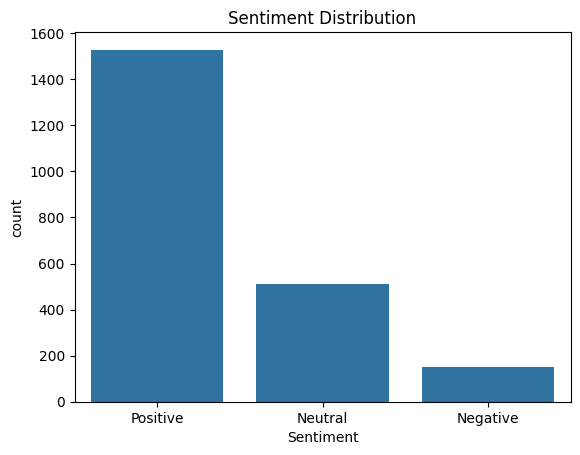

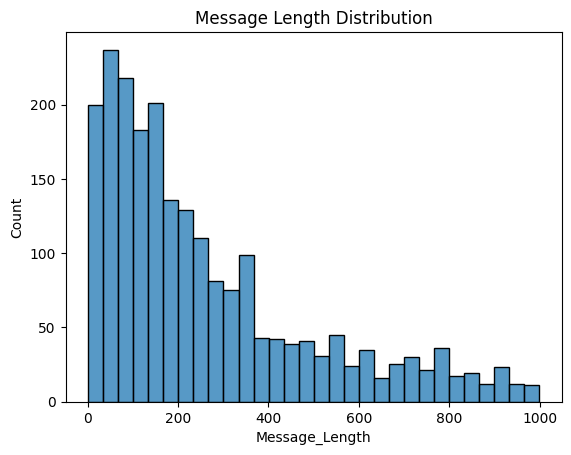

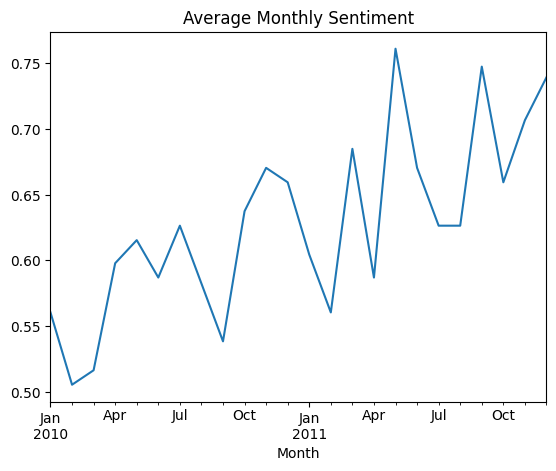

In [13]:
#Sentiment Distribution
plt.figure()
sns.countplot(x='Sentiment', data=df)
plt.title("Sentiment Distribution")
plt.savefig("visualizations/sentiment_distribution.png", bbox_inches='tight')
plt.show()

#Message Length
df['Message_Length'] = df['body'].apply(len)

plt.figure()
sns.histplot(df['Message_Length'], bins=30)
plt.title("Message Length Distribution")
plt.savefig("visualizations/message_length_distribution.png", bbox_inches='tight')
plt.show()

#Monthly Sentiment Trend
monthly_trend = df.groupby('Month')['Score'].mean()

plt.figure()
monthly_trend.plot()
plt.title("Average Monthly Sentiment")
plt.savefig("visualizations/monthly_sentiment_trend.png", bbox_inches='tight')
plt.show()

TASK 3 – MONTHLY SCORING

In [14]:
monthly_scores = df.groupby(['Employee_ID','Month'])['Score'].sum().reset_index()

monthly_scores.head()

,Employee_ID,Month,Score
0,bobette.riner@ipgdirect.com,2010-01,1
1,bobette.riner@ipgdirect.com,2010-02,7
2,bobette.riner@ipgdirect.com,2010-03,6
3,bobette.riner@ipgdirect.com,2010-04,3
4,bobette.riner@ipgdirect.com,2010-05,2


TASK 4 – EMPLOYEE RANKING

In [ ]:
# Top 3 Positive
top_positive = monthly_scores.sort_values(
    by=['Month','Score','Employee_ID'],
    ascending=[True, False, True]
).groupby('Month').head(3)

print("Top Positive Employees:")
top_positive



Top Positive Employees:


,Employee_ID,Month,Score
120,kayne.coulter@enron.com,2010-01,13
48,eric.bass@enron.com,2010-01,9
144,lydia.delgado@enron.com,2010-01,9
73,john.arnold@enron.com,2010-02,11
97,johnny.palmer@enron.com,2010-02,10
...,...,...,...
94,john.arnold@enron.com,2011-11,10
22,bobette.riner@ipgdirect.com,2011-11,9
71,eric.bass@enron.com,2011-12,12
191,patti.thompson@enron.com,2011-12,12


In [16]:
# Top 3 Negative
top_negative = monthly_scores.sort_values(
    by=['Month','Score','Employee_ID'],
    ascending=[True, True, True]
).groupby('Month').head(3)

print("Top Negative Employees:")
top_negative

Top Negative Employees:


,Employee_ID,Month,Score
0,bobette.riner@ipgdirect.com,2010-01,1
96,johnny.palmer@enron.com,2010-01,1
192,rhonda.denton@enron.com,2010-01,1
121,kayne.coulter@enron.com,2010-02,1
145,lydia.delgado@enron.com,2010-02,1
...,...,...,...
214,rhonda.denton@enron.com,2011-11,2
46,don.baughman@enron.com,2011-11,5
119,johnny.palmer@enron.com,2011-12,2
23,bobette.riner@ipgdirect.com,2011-12,3


TASK 5 – FLIGHT RISK

In [17]:
df = df.sort_values(by=['Employee_ID','date'])

df['Neg_Flag'] = (df['Sentiment'] == "Negative").astype(int)

rolling_neg = (
    df.set_index('date')
      .groupby('Employee_ID')['Neg_Flag']
      .rolling('30D')
      .sum()
      .reset_index()
)

flight_risk = rolling_neg[rolling_neg['Neg_Flag'] >= 4]['Employee_ID'].unique()

print("Flight Risk Employees:")
print(flight_risk)

Flight Risk Employees:
['bobette.riner@ipgdirect.com' 'don.baughman@enron.com'
 'johnny.palmer@enron.com' 'sally.beck@enron.com']


TASK 6 – LINEAR REGRESSION

MSE: 3.3496574465159115
R2 Score: 0.7183250937343457


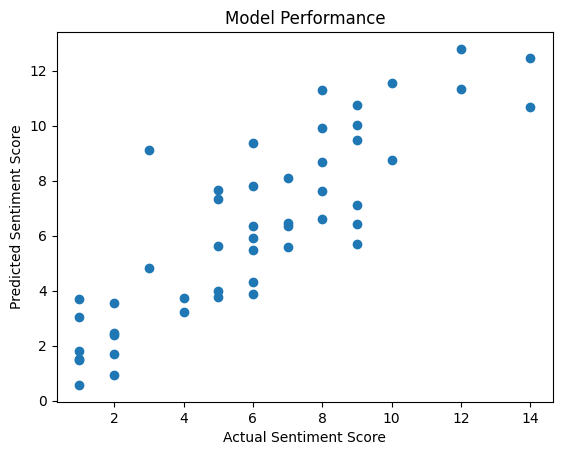

In [19]:
monthly_features = df.groupby(['Employee_ID','Month']).agg({
    'Score': 'sum',
    'body': 'count',
    'Message_Length': 'mean'
}).reset_index()

monthly_features.columns = [
    'Employee_ID',
    'Month',
    'Sentiment_Score',
    'Message_Count',
    'Avg_Message_Length'
]

monthly_features.head()

X = monthly_features[['Message_Count','Avg_Message_Length']]
y = monthly_features['Sentiment_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, predictions))
print("R2 Score:", r2_score(y_test, predictions))

plt.figure()
plt.scatter(y_test, predictions)
plt.xlabel("Actual Sentiment Score")
plt.ylabel("Predicted Sentiment Score")
plt.title("Model Performance")
plt.savefig("visualizations/model_performance.png", bbox_inches='tight')
plt.show()